In [17]:
import numpy as np
import matplotlib.pyplot as plt

#np.random.seed(847063)

# Exercício 1

Considere a variável aleatória contínua $X$ com densidade

$$
f(x)=20x(1-x)^3, \qquad 0\leq x\leq 1,
$$

e $f(x)=0$ fora do intervalo $[0,1]$.

1. Utilizando o método de Aceitação-Rejeição (AR), gere uma amostra i.i.d. de tamanho $n$ da distribuição com densidade $f$. Utilize como distribuição proposta uma distribuição Uniforme em $[0,1]$.

   Para determinar a constante $M$ do método de Aceitação-Rejeição, aproxime numericamente o máximo de $f$ no intervalo $[0,1]$. Para isso, construa uma malha suficientemente fina utilizando `np.linspace`, avalie a função $f$ nos pontos dessa malha e utilize `np.max` para obter uma aproximação de

$$
M = \max_{0\leq x\leq 1} f(x).
$$

2. Faça um gráfico contendo a densidade teórica $f(x)$ e o histograma normalizado da amostra gerada. Compare visualmente a distribuição da amostra com a densidade teórica.

3. Para cada observação gerada, registre o número de tentativas necessárias até ocorrer a primeira aceitação.

   a. Determine teoricamente a probabilidade de aceitação do método AR.

   b. Determine o número esperado de tentativas até a primeira aceitação.

   c. Compare a média empírica do número de tentativas com o valor esperado teoricamente.

   d. Determine a distribuição teórica do número de tentativas até a primeira aceitação e compare-a com a distribuição empírica obtida na simulação.

2.159374985935312


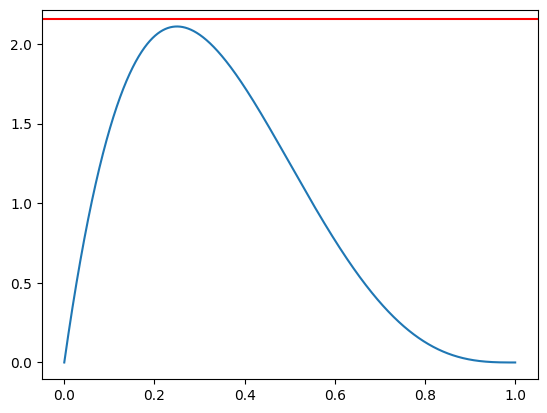

In [18]:
def f(x):
  return 20*x*((1-x)**3)

valor = []
for x in np.linspace(0, 1, 10_000):
  valor.append(f(x))

c = np.max(valor)+0.05
print(c)

x = np.linspace(0, 1, 10_000)
plt.plot(x, valor)
plt.axhline(y=c, color='red', linestyle='-')
plt.show()

In [19]:
contagem = 0
amostra = []
while len(amostra) < 10_000:
  contagem += 1
  u = np.random.uniform()
  y = np.random.uniform()
  if(u < f(y)/c):
    amostra.append(y)


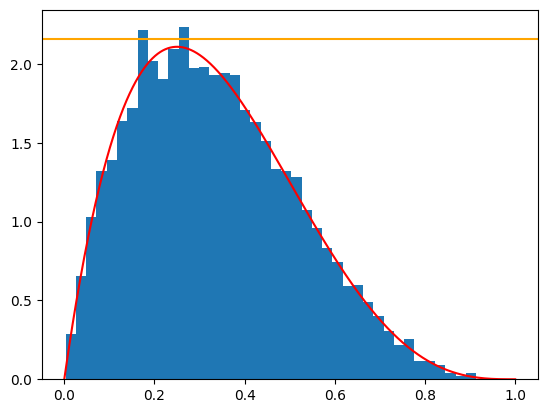

In [20]:
plt.hist(amostra, density=True, bins=40)
plt.plot(np.linspace(0, 1, 10_000), valor, color='red')
plt.axhline(y=c, color='orange', linestyle='-')
plt.show()

In [21]:
print(print(f"Aceitação obtida: {10_000/contagem} \nAceitação teorica: {1/c}"))

Aceitação obtida: 0.46108447067502767 
Aceitação teorica: 0.46309696394248995
None


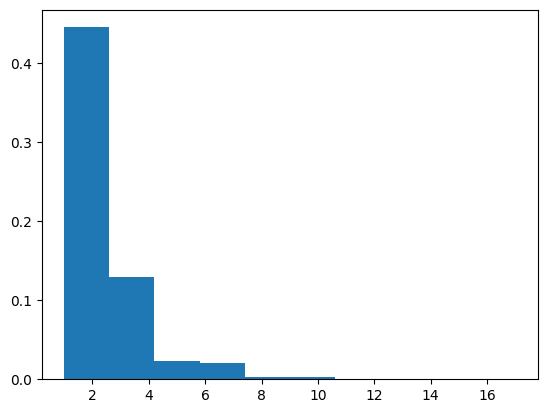

In [22]:
contagem = 0
tentativas = []
amostra = []
while len(amostra) < 10_000:
  contagem += 1
  u = np.random.uniform()
  y = np.random.uniform()
  if(u < f(y)/c):
    amostra.append(y)
    tentativas.append(contagem)
    contagem = 0

plt.hist(tentativas, density=True)
plt.show()

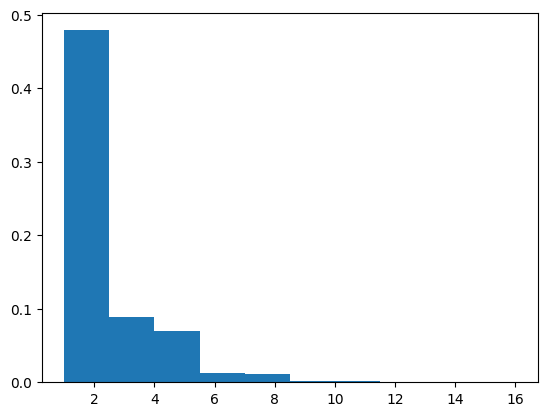

In [23]:
def geometrica(p, M):
  amostra = []
  for i in range(M):
    j = np.ceil(np.log(1 - np.random.uniform())/np.log(1-p))
    amostra.append(j)
  return amostra

dados = geometrica(1/c, 10_000)

plt.hist(dados, density=True)
plt.show()

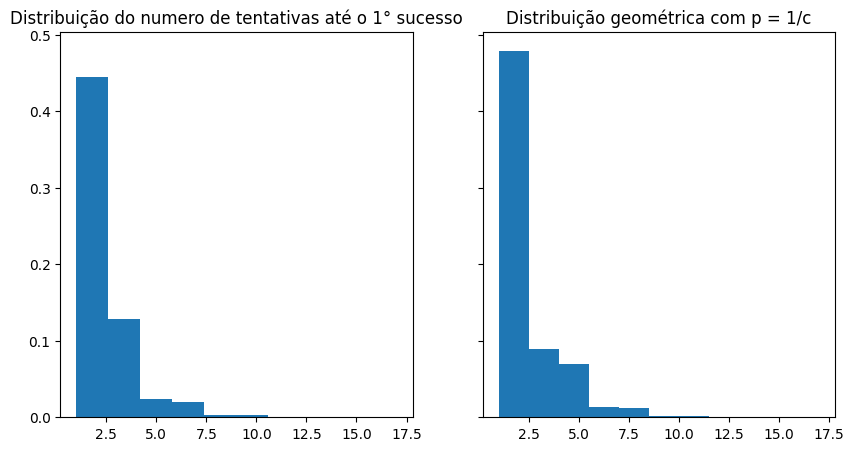

In [25]:
fig, ax = plt.subplots(1, 2, figsize=(10, 5), sharex=True, sharey=True)
ax[0].hist(tentativas, density=True)
ax[0].set_title('Distribuição do numero de tentativas até o 1° sucesso')

ax[1].hist(dados, density=True)
ax[1].set_title('Distribuição geométrica com p = 1/c')

plt.show()